Implementação

In [1]:
# ==========================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ==========================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
from sklearn.metrics import classification_report, confusion_matrix
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# Reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

# ==========================================
# 2. CARREGAMENTO DOS DADOS (.npz)
# ==========================================
DATA_PATH = "/kaggle/input/datasets/lscolombo/pamap2-for-rp/pamap2_for_rp.npz"

print("Carregando dados...")
data = np.load(DATA_PATH)

# O arquivo .npz já possui os splits de treino, validação e teste prontos
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

num_classes = len(np.unique(y_train))
print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_val: {X_val.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Número de classes: {num_classes}")

# ==========================================
# 3. PRÉ-COMPUTAÇÃO DE FEATURES E DATASETS (OTIMIZADO)
# ==========================================
# Índices (0 a 39) baseados na sua lista de COLUMNS no pamap2.ipynb
idx_x = [2, 8, 15, 21, 28, 34]
idx_y = [3, 9, 16, 22, 29, 35]
idx_z = [4, 10, 17, 23, 30, 36]
idx_inertial_all = idx_x + idx_y + idx_z
idx_others = [i for i in range(40) if i not in idx_inertial_all]

def compute_urp_images_and_1d(X, target_img_size=(112, 112)):
    n_samples = len(X)
    X_img = np.zeros((n_samples, target_img_size[0], target_img_size[1], 3), dtype=np.float32)
    X_1d = X[:, :, idx_others]

    for i in range(n_samples):
        window = X[i]
        dist_r = squareform(pdist(window[:, idx_x], metric='euclidean'))
        dist_g = squareform(pdist(window[:, idx_y], metric='euclidean'))
        dist_b = squareform(pdist(window[:, idx_z], metric='euclidean'))

        img = np.stack([dist_r, dist_g, dist_b], axis=-1)
        img_min, img_max = img.min(), img.max()
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)

        img = (1.0 - img) ** 3
        X_img[i] = cv2.resize(img, target_img_size, interpolation=cv2.INTER_LINEAR)

    return X_img, X_1d

print("\nPré-computando imagens URP (isso pode levar alguns minutos, mas será feito apenas UMA vez)...")
X_train_img, X_train_1d = compute_urp_images_and_1d(X_train)
X_val_img, X_val_1d = compute_urp_images_and_1d(X_val)
X_test_img, X_test_1d = compute_urp_images_and_1d(X_test)

# Criando tf.data.Datasets altamente otimizados para a GPU
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices(((X_train_img, X_train_1d), y_train)) \
    .shuffle(buffer_size=1024) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(((X_val_img, X_val_1d), y_val)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(((X_test_img, X_test_1d), y_test)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

print("Datasets criados com sucesso e prontos para alimentar a GPU!")

# ==========================================
# 4. CONSTRUÇÃO DO MODELO LATE FUSION
# ==========================================
def build_late_fusion_model(num_classes, num_other_features=len(idx_others), window_size=512):
    input_img = layers.Input(shape=(112, 112, 3), name="input_urp_img")

    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
    for layer in base_resnet.layers[:-15]:
        layer.trainable = False

    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(128, activation='relu')(x_img)
    x_img = layers.Dropout(0.3)(x_img)

    input_1d = layers.Input(shape=(window_size, num_other_features), name="input_1d_series")

    x_1d = layers.Conv1D(filters=32, kernel_size=3, activation='relu')(input_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu')(x_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Flatten()(x_1d)
    x_1d = layers.Dense(64, activation='relu')(x_1d)

    merged = layers.concatenate([x_img, x_1d])

    z = layers.Dense(64, activation='relu')(merged)
    z = layers.Dropout(0.3)(z)
    output = layers.Dense(num_classes, activation='softmax', name="output_class")(z)

    model = models.Model(inputs=[input_img, input_1d], outputs=output)
    return model

model = build_late_fusion_model(num_classes=num_classes, window_size=250)

# ==========================================
# 5. COMPILAÇÃO E TREINAMENTO BASE
# ==========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

print("\nIniciando Treinamento Rápido...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

2026-04-25 03:20:19.619424: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777087219.810544      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777087219.870306      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777087220.329123      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777087220.329158      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777087220.329161      55 computation_placer.cc:177] computation placer alr

Carregando dados...
Shape X_train: (9136, 250, 40)
Shape X_val: (2080, 250, 40)
Shape X_test: (4144, 250, 40)
Número de classes: 12

Pré-computando imagens URP (isso pode levar alguns minutos, mas será feito apenas UMA vez)...


I0000 00:00:1777087297.563306      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777087297.569259      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets criados com sucesso e prontos para alimentar a GPU!
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Iniciando Treinamento Rápido...
Epoch 1/20


I0000 00:00:1777087316.930330     141 service.cc:152] XLA service 0x7a1220003360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777087316.930383     141 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777087316.930389     141 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777087319.116641     141 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/286 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.0382 - loss: 13.3091      

I0000 00:00:1777087326.703075     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


286/286 ━━━━━━━━━━━━━━━━━━━━ 43s 82ms/step - accuracy: 0.4097 - loss: 2.6717 - val_accuracy: 0.2139 - val_loss: 3.2345 - learning_rate: 5.0000e-04
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.6790 - loss: 1.0989 - val_accuracy: 0.2279 - val_loss: 3.8767 - learning_rate: 5.0000e-04
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.7860 - loss: 0.6791 - val_accuracy: 0.3240 - val_loss: 4.3639 - learning_rate: 5.0000e-04
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.8304 - loss: 0.5451 - val_accuracy: 0.3236 - val_loss: 4.3693 - learning_rate: 2.5000e-04
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.8584 - loss: 0.4388 - val_accuracy: 0.3005 - val_loss: 4.4682 - learning_rate: 2.5000e-04
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.8858 - loss: 0.3547 - val_accuracy: 0.3087 - val_loss: 4.8054 - learning_rate: 1.2500e-04



Gerando amostras de Recurrence Plots (URP) para cada classe...


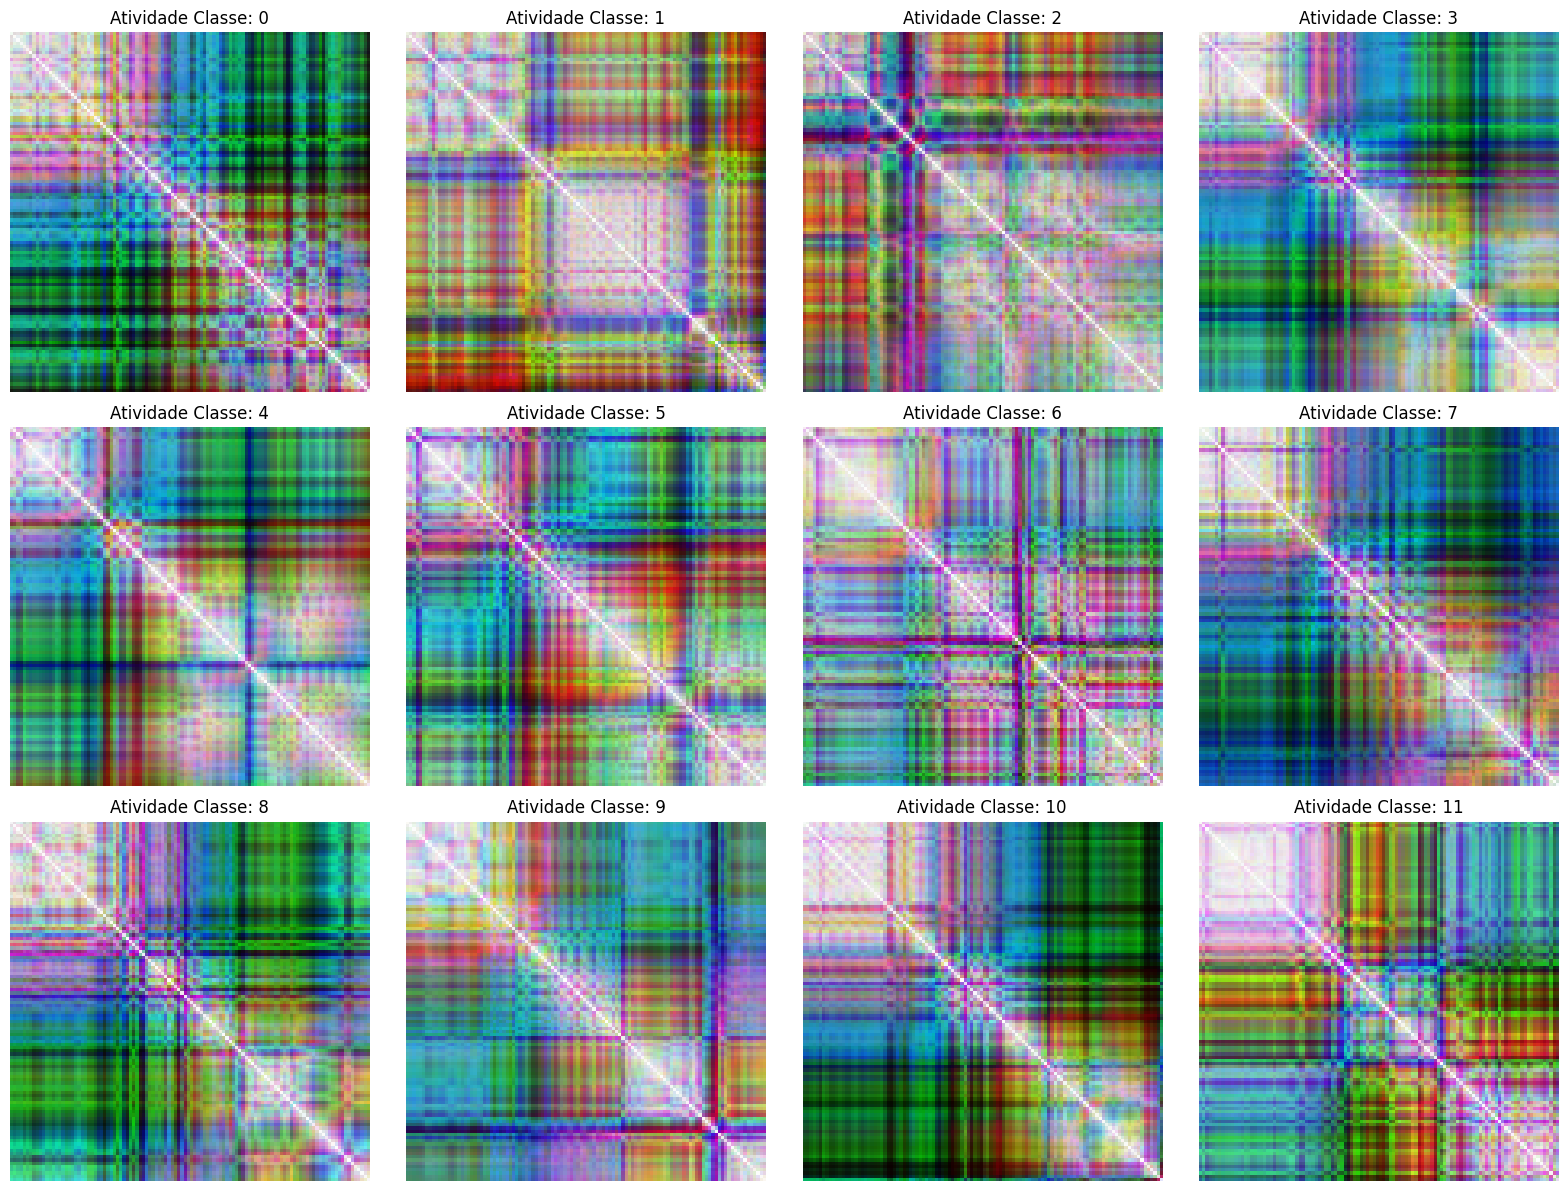

In [2]:
# ==========================================
# 7. VISUALIZAÇÃO DOS RECURRENCE PLOTS (URP) POR CLASSE
# ==========================================
print("\nGerando amostras de Recurrence Plots (URP) para cada classe...")

# Identificar todas as classes únicas no conjunto de treinamento
unique_classes = np.unique(y_train)
num_unique_classes = len(unique_classes)

# Configurar o grid do matplotlib para as imagens (ex: 4 colunas)
cols = 4
rows = int(np.ceil(num_unique_classes / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, cls in enumerate(unique_classes):
    # Pegar o índice do primeiro exemplo encontrado para esta classe
    sample_idx = np.where(y_train == cls)[0][0]
    window = X_train[sample_idx]

    # Gerar as matrizes de distância para os 3 eixos espaciais (RGB)
    dist_r = squareform(pdist(window[:, idx_x], metric='euclidean'))
    dist_g = squareform(pdist(window[:, idx_y], metric='euclidean'))
    dist_b = squareform(pdist(window[:, idx_z], metric='euclidean'))

    # Empilhar nos canais de cor
    img = np.stack([dist_r, dist_g, dist_b], axis=-1)

    # Aplicar a normalização Min-Max
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)

    # Inverter contraste e aplicar transformação cúbica para realçar os padrões
    img = (1.0 - img) ** 3

    # Redimensionar para o tamanho exato que a ResNet50 enxerga (112x112)
    img_resized = cv2.resize(img, (112, 112), interpolation=cv2.INTER_LINEAR)

    # Plotar a imagem
    ax = axes[i]
    ax.imshow(img_resized)

    # Como o LabelEncoder já transformou para inteiros, mostraremos o ID numérico da classe
    # (Se você salvou as classes do LabelEncoder, poderia mapear o nome aqui)
    ax.set_title(f'Atividade Classe: {cls}', fontsize=12)
    ax.axis('off')

# Ocultar os eixos (subplots) que sobrarem vazios no grid
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Experimento 1: Treinamento com Classes Balanceadas
Aqui vamos calcular os pesos para cada classe para que o modelo preste mais atenção em classes sub-representadas durante o treinamento.

In [3]:
# ==========================================
# FUNÇÕES DE AVALIAÇÃO PADRONIZADA
# ==========================================
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, f1_score

def plot_learning_curve(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Treino')
    ax1.plot(history.history['val_loss'], label='Validação')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Treino')
    ax2.plot(history.history['val_accuracy'], label='Validação')
    ax2.set_title(f'{title} - Acurácia')
    ax2.set_xlabel('Épocas')
    ax2.set_ylabel('Acurácia')
    ax2.legend()

    plt.tight_layout()
    plt.show()

def plot_urp_samples(X, y):
    print("\nGerando amostras de Recurrence Plots (URP) para esta avaliação...")
    unique_classes = np.unique(y)
    cols = 4
    rows = int(np.ceil(len(unique_classes) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = axes.flatten()

    for i, cls in enumerate(unique_classes):
        sample_idx = np.random.choice(np.where(y == cls)[0])
        window = X[sample_idx]

        dist_r = squareform(pdist(window[:, idx_x], metric='euclidean'))
        dist_g = squareform(pdist(window[:, idx_y], metric='euclidean'))
        dist_b = squareform(pdist(window[:, idx_z], metric='euclidean'))
        img = np.stack([dist_r, dist_g, dist_b], axis=-1)

        img_min, img_max = img.min(), img.max()
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)
        img = (1.0 - img) ** 3
        img_resized = cv2.resize(img, (112, 112), interpolation=cv2.INTER_LINEAR)

        axes[i].imshow(img_resized)
        axes[i].set_title(f'Classe: {cls}')
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

def evaluate_experiment(model, history, test_dataset, y_true_real, X_teste_bruto, experiment_name):
    print(f"\n{'='*50}")
    print(f" RESULTADOS: {experiment_name}")
    print(f"{'='*50}")

    # 1. Curva de Aprendizado
    if history is not None:
        plot_learning_curve(history, experiment_name)

    # Previsões para as métricas
    print("\nRealizando previsões no conjunto de teste...")
    y_pred_probs = model.predict(test_dataset)
    y_pred = np.argmax(y_pred_probs, axis=1)

    y_true = y_true_real

    # 2. Bootstrap para Acurácia e F1-Score
    print("\nCalculando métricas via Bootstrap (200 iterações)...")
    n_iterations = 200
    n_size = len(y_true)
    acc_scores, f1_scores = [], []

    for _ in range(n_iterations):
        indices = resample(np.arange(n_size))
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]

        acc_scores.append(accuracy_score(y_true_boot, y_pred_boot))
        f1_scores.append(f1_score(y_true_boot, y_pred_boot, average='macro'))

    mean_acc, std_acc = np.mean(acc_scores), np.std(acc_scores)
    mean_f1, std_f1 = np.mean(f1_scores), np.std(f1_scores)

    print(f"➤ Acurácia Média: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"➤ F1-Score Média (Macro): {mean_f1:.4f} ± {std_f1:.4f}")

    # 3. Relatório de Classificação
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred))

    # 4. Matriz de Confusão
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {experiment_name}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.show()

    # 5. URP Plots de instâncias (aleatórias do teste)
    plot_urp_samples(X_teste_bruto, y_true_real)

Pesos das classes calculados:
Classe 0: 0.7906
Classe 1: 0.8545
Classe 2: 0.8108
Classe 3: 0.6403
Classe 4: 2.8302
Classe 5: 1.0206
Classe 6: 0.9021
Classe 7: 1.2339
Classe 8: 1.3523
Classe 9: 0.9096
Classe 10: 0.7109
Classe 11: 3.6779

Iniciando Treinamento - Experimento 1 (Balanced)...
Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 0.3461 - loss: 2.6764 - val_accuracy: 0.1538 - val_loss: 3.2142 - learning_rate: 5.0000e-04
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.5292 - loss: 1.3552 - val_accuracy: 0.1543 - val_loss: 4.2592 - learning_rate: 5.0000e-04
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.6337 - loss: 1.0615 - val_accuracy: 0.2909 - val_loss: 4.3210 - learning_rate: 5.0000e-04
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.7478 - loss: 0.7367 - val_accuracy: 0.1832 - val_loss: 5.5955 - learning_rate: 2.5000e-04
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.7659 - loss

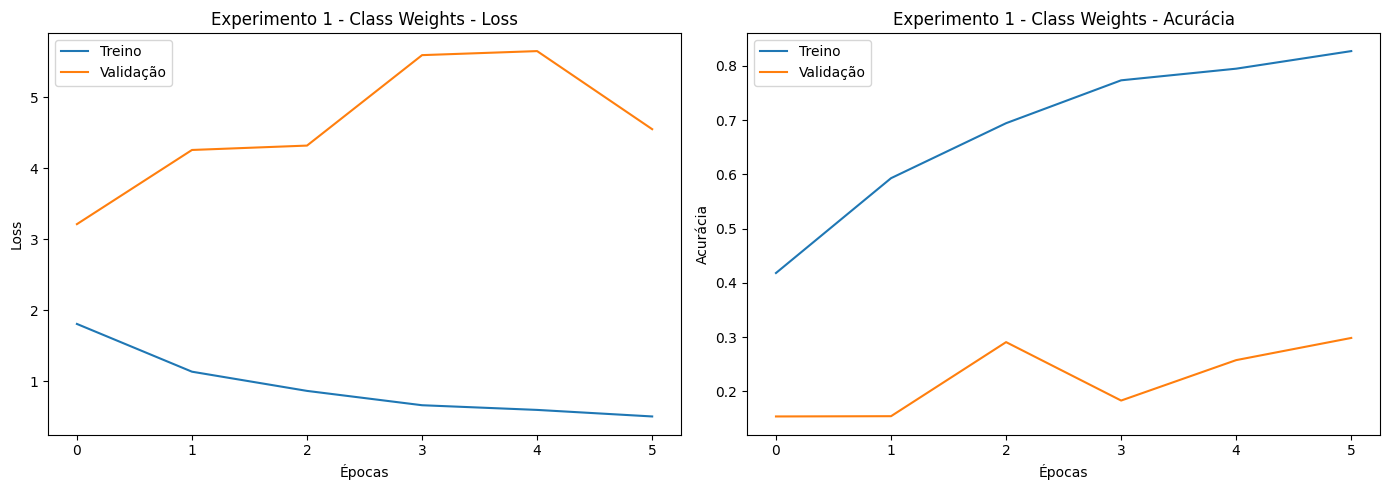


Realizando previsões no conjunto de teste...
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step

Calculando métricas via Bootstrap (200 iterações)...
➤ Acurácia Média: 0.3569 ± 0.0071
➤ F1-Score Média (Macro): 0.2655 ± 0.0061

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       373
           1       0.84      0.47      0.61       396
           2       0.77      0.07      0.12       369
           3       0.00      0.00      0.00       459
           4       0.20      0.93      0.33       377
           5       0.80      0.13      0.23       357
           6       0.00      0.00      0.00       421
           7       0.50      0.01      0.02       218
           8       0.08      0.40      0.14       189
           9       0.29      0.04      0.07       361
          10       0.58      0.76      0.65       563
          11       0.08      0.03      0.05        61

    accuracy                           0.36     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


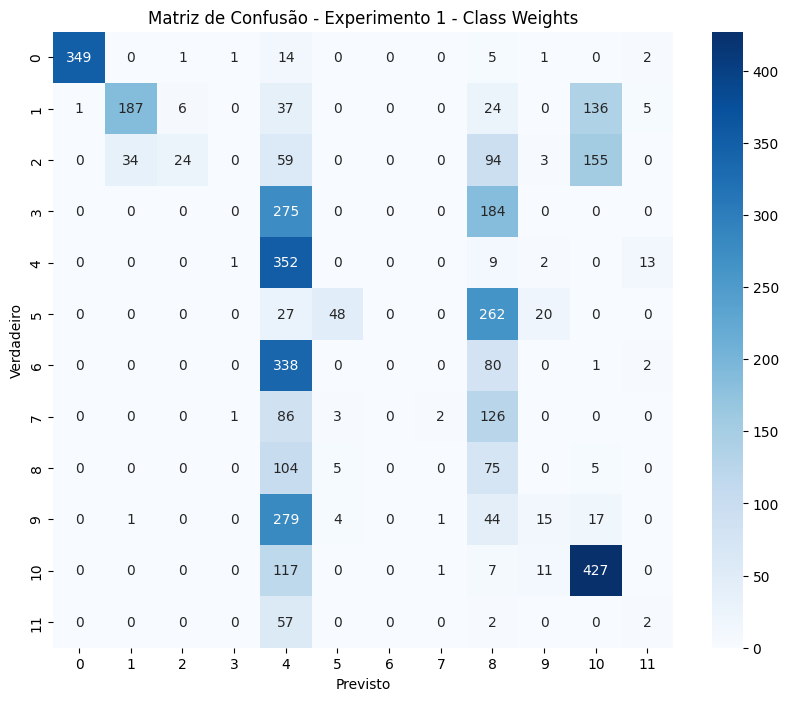


Gerando amostras de Recurrence Plots (URP) para esta avaliação...


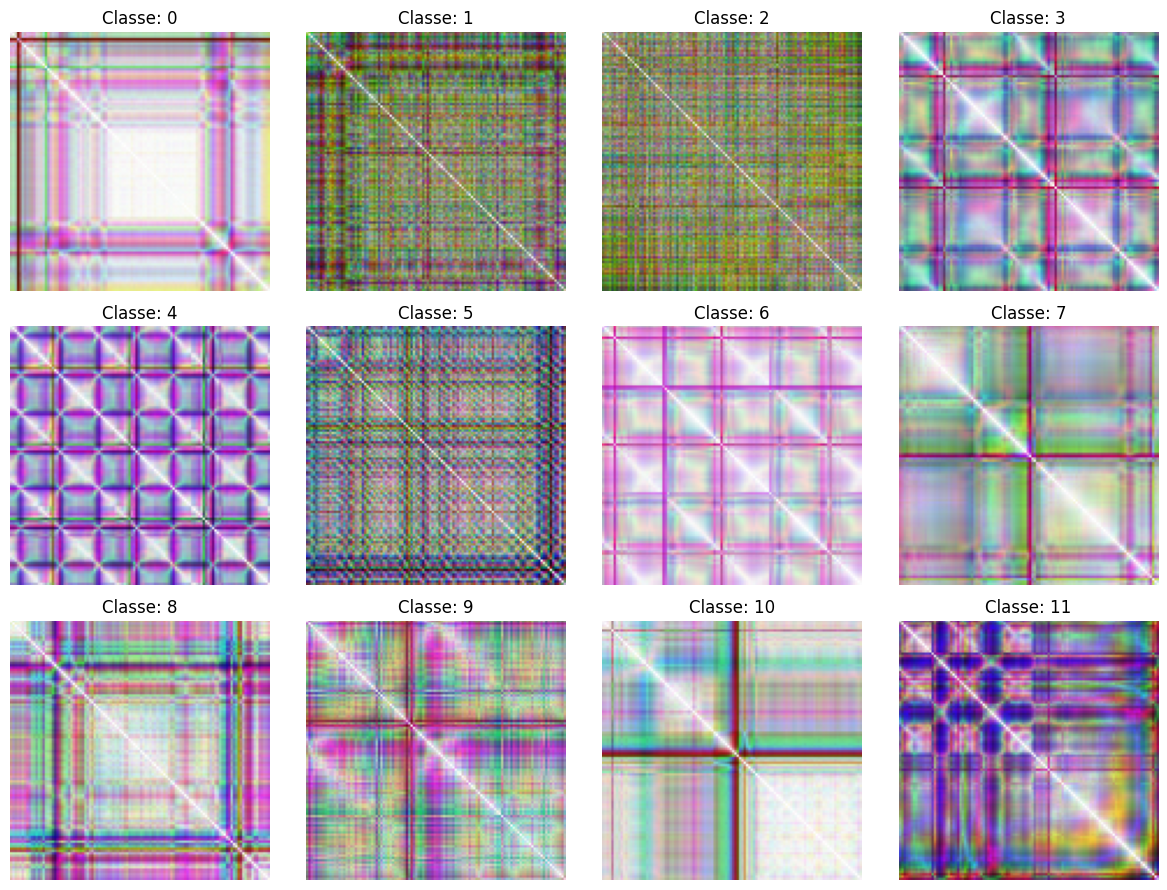

In [4]:
# ==========================================
# EXPERIMENTO 1: Treinamento com Class Weights
# ==========================================
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Pesos das classes calculados:")
for c, w in class_weight_dict.items():
    print(f"Classe {c}: {w:.4f}")

model_exp1 = build_late_fusion_model(num_classes=num_classes, window_size=250)
model_exp1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nIniciando Treinamento - Experimento 1 (Balanced)...")
history_exp1 = model_exp1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr]
)

evaluate_experiment(model_exp1, history_exp1, test_dataset, y_test, X_test, "Experimento 1 - Class Weights")

## Experimento 2: Otimização de Hiperparâmetros com Optuna
Instalaremos o Optuna e rodaremos um *study* para buscar os melhores hiperparâmetros (Learning Rate, Unidades Densas e Dropout).

In [5]:
!pip install optuna

[I 2026-04-25 03:25:23,126] A new study created in memory with name: no-name-83bbc372-932c-4da2-9c04-208f952de60c


Iniciando estudo Optuna...


[I 2026-04-25 03:26:48,453] Trial 0 finished with value: 0.45336538553237915 and parameters: {'learning_rate': 6.254844706318484e-05, 'dense_units_1d': 32, 'dropout_rate': 0.5467390746972962}. Best is trial 0 with value: 0.45336538553237915.
[I 2026-04-25 03:28:13,512] Trial 1 finished with value: 0.17740385234355927 and parameters: {'learning_rate': 0.00013102409552421648, 'dense_units_1d': 128, 'dropout_rate': 0.4927026956474339}. Best is trial 0 with value: 0.45336538553237915.
[I 2026-04-25 03:29:38,380] Trial 2 finished with value: 0.23509615659713745 and parameters: {'learning_rate': 4.731810250437485e-05, 'dense_units_1d': 128, 'dropout_rate': 0.2866762068678041}. Best is trial 0 with value: 0.45336538553237915.
[I 2026-04-25 03:31:03,091] Trial 3 finished with value: 0.32403847575187683 and parameters: {'learning_rate': 2.9882280351878857e-05, 'dense_units_1d': 64, 'dropout_rate': 0.21677634088729758}. Best is trial 0 with value: 0.45336538553237915.
[I 2026-04-25 03:32:27,851]


--- Resultados Optuna ---
Melhores Hiperparâmetros: {'learning_rate': 1.4676969795566694e-05, 'dense_units_1d': 64, 'dropout_rate': 0.49651536237614013}

Retreinando modelo com os melhores hiperparâmetros por 20 épocas...
Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 37s 77ms/step - accuracy: 0.1366 - loss: 9.7936 - val_accuracy: 0.2101 - val_loss: 2.5666 - learning_rate: 1.4677e-05
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.2893 - loss: 2.6559 - val_accuracy: 0.3567 - val_loss: 2.3090 - learning_rate: 1.4677e-05
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.3747 - loss: 2.1157 - val_accuracy: 0.3712 - val_loss: 2.2171 - learning_rate: 1.4677e-05
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.4357 - loss: 1.8268 - val_accuracy: 0.4067 - val_loss: 2.0853 - learning_rate: 1.4677e-05
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.4977 - loss: 1.6029 - val_accuracy: 0.3808 - val_loss: 2.0177 - learning_rate

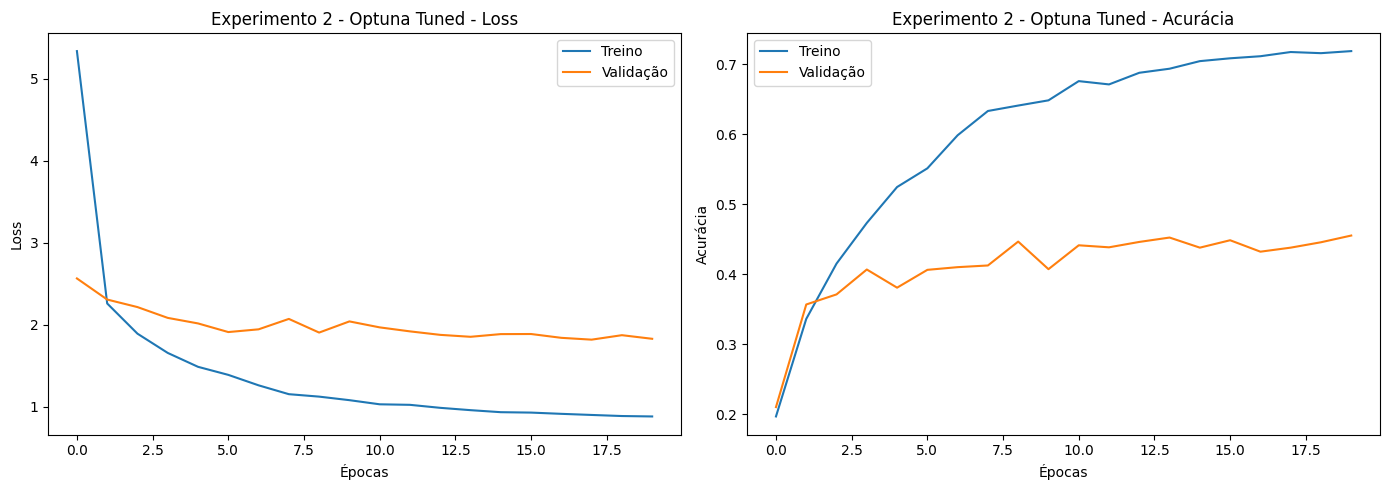


Realizando previsões no conjunto de teste...
130/130 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step

Calculando métricas via Bootstrap (200 iterações)...
➤ Acurácia Média: 0.7149 ± 0.0071
➤ F1-Score Média (Macro): 0.6181 ± 0.0066

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       373
           1       0.74      0.40      0.52       396
           2       0.51      0.26      0.34       369
           3       0.74      0.85      0.79       459
           4       0.87      0.89      0.88       377
           5       0.88      0.95      0.91       357
           6       0.67      0.95      0.79       421
           7       0.48      0.31      0.38       218
           8       0.57      0.46      0.51       189
           9       0.70      0.63      0.66       361
          10       0.62      0.90      0.74       563
          11       0.00      0.00      0.00        61

    accuracy                           0.72     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


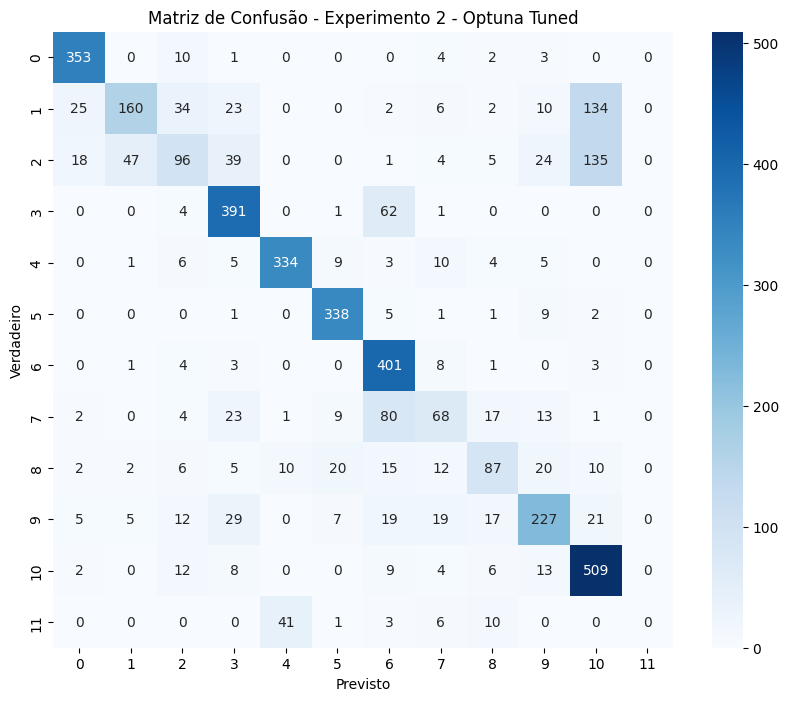


Gerando amostras de Recurrence Plots (URP) para esta avaliação...


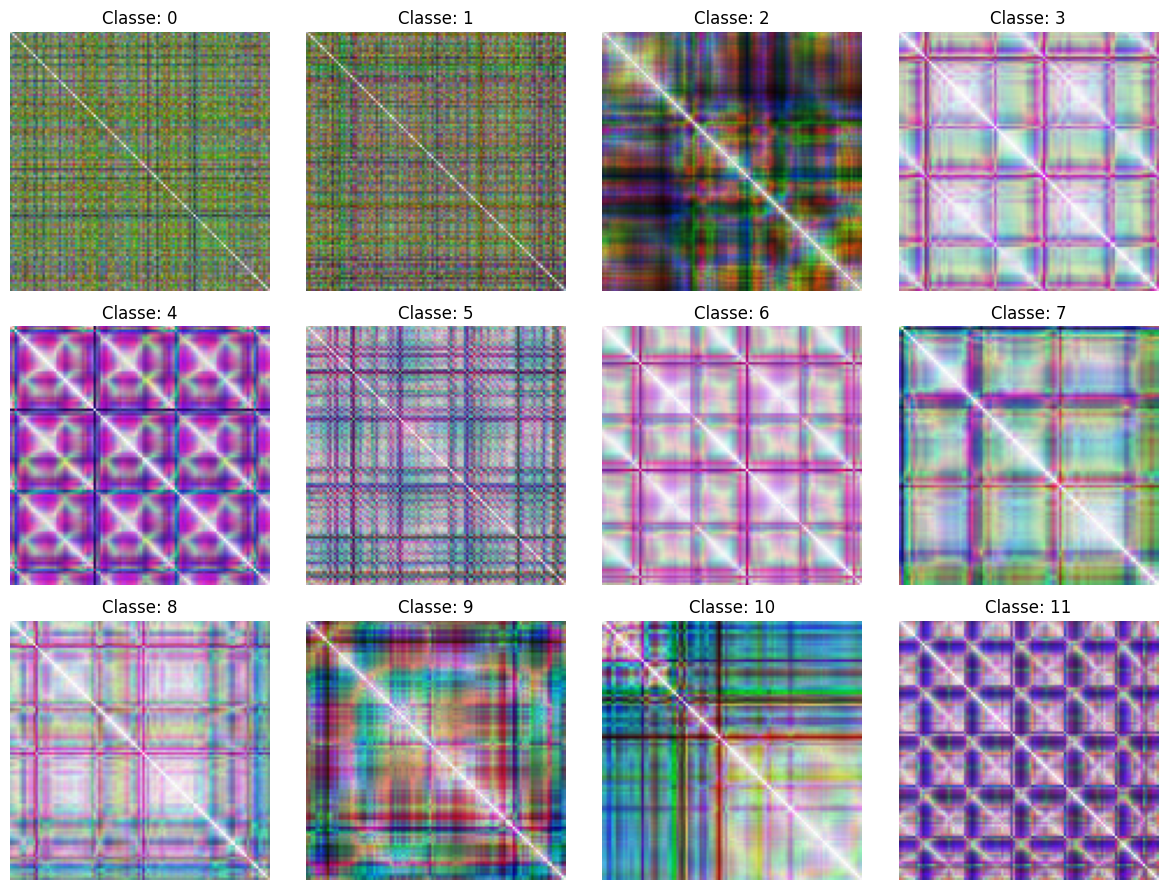

In [6]:
# ==========================================
# EXPERIMENTO 2: Otimização com Optuna
# ==========================================
import optuna
import tensorflow as tf

def objective(trial):
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    dense_units_1d = trial.suggest_categorical('dense_units_1d', [32, 64, 128])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.6)

    tf.keras.backend.clear_session()

    input_img = layers.Input(shape=(112, 112, 3), name="input_urp_img")
    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
    for layer in base_resnet.layers[:-15]:
        layer.trainable = False

    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(128, activation='relu')(x_img)
    x_img = layers.Dropout(dropout_rate)(x_img)

    input_1d = layers.Input(shape=(250, len(idx_others)), name="input_1d_series")
    x_1d = layers.Conv1D(filters=32, kernel_size=3, activation='relu')(input_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu')(x_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Flatten()(x_1d)
    x_1d = layers.Dense(dense_units_1d, activation='relu')(x_1d)

    merged = layers.concatenate([x_img, x_1d])
    z = layers.Dense(64, activation='relu')(merged)
    z = layers.Dropout(dropout_rate)(z)
    output = layers.Dense(num_classes, activation='softmax', name="output_class")(z)

    model_opt = models.Model(inputs=[input_img, input_1d], outputs=output)

    model_opt.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model_opt.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=5,
        verbose=0
    )

    val_acc = history.history['val_accuracy'][-1]
    return val_acc

print("Iniciando estudo Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

print("\n--- Resultados Optuna ---")
print("Melhores Hiperparâmetros:", study.best_params)

# --- Retreinamento com os Melhores Parâmetros ---
print("\nRetreinando modelo com os melhores hiperparâmetros por 20 épocas...")
tf.keras.backend.clear_session()

input_img = layers.Input(shape=(112, 112, 3), name="input_urp_img")
base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
for layer in base_resnet.layers[:-15]:
    layer.trainable = False

x_img = base_resnet.output
x_img = layers.GlobalAveragePooling2D()(x_img)
x_img = layers.Dense(128, activation='relu')(x_img)
x_img = layers.Dropout(study.best_params['dropout_rate'])(x_img)

input_1d = layers.Input(shape=(250, len(idx_others)), name="input_1d_series")
x_1d = layers.Conv1D(filters=32, kernel_size=3, activation='relu')(input_1d)
x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu')(x_1d)
x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
x_1d = layers.Flatten()(x_1d)
x_1d = layers.Dense(study.best_params['dense_units_1d'], activation='relu')(x_1d)

merged = layers.concatenate([x_img, x_1d])
z = layers.Dense(64, activation='relu')(merged)
z = layers.Dropout(study.best_params['dropout_rate'])(z)
output = layers.Dense(num_classes, activation='softmax', name="output_class")(z)

best_model = models.Model(inputs=[input_img, input_1d], outputs=output)
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=study.best_params['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_opt = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

evaluate_experiment(best_model, history_opt, test_dataset, y_test, X_test, "Experimento 2 - Optuna Tuned")